# 2장 4강: 이벤트 로그 기반 AARRR 퍼널 집계 및 시각화 — 실습문제

## 실습 목표

- 계정·구독·기능 사용 데이터를 연결하여 퍼널 단계 도달 기록을 만들 수 있다.
- `groupby()`와 `nunique()`로 단계별 고유 계정 수를 집계할 수 있다.
- 전 단계 대비 전환율과 최초 단계 대비 전체 전환율을 계산할 수 있다.
- 퍼널을 가로 막대그래프로 시각화하고 이탈 집중 구간을 찾을 수 있다.
- 수치에서 확인한 이탈 구간을 바탕으로 개선 가설과 검증 방법을 제안할 수 있다.

## 실습 환경 / 데이터

- Python
- pandas
- matplotlib
- `ravenstack_accounts.csv`
- `ravenstack_subscriptions.csv`
- `ravenstack_feature_usage.csv`

Ravenstack은 구독형 B2B SaaS입니다. 이번 실습에서는 다음 네 단계를 누적 퍼널로 정의합니다.

| 단계 | 도달 조건 |
|---|---|
| Acquisition | 관찰 종료일보다 30일 이상 앞서 가입한 계정 |
| Activation | 가입 후 30일 이내 첫 구독을 시작한 계정 |
| Retention | Activation 계정 중 첫 구독 시작 30일 후에도 유효한 기능 사용 기록이 있는 계정 |
| Revenue | Retention 계정 중 첫 구독이 체험판이 아니고 `mrr_amount > 0`인 계정 |

> Ravenstack 데이터에는 다른 사용자를 추천한 행동을 뜻하는 Referral 이벤트가 없습니다. `referral_source`는 **현재 계정이 유입된 경로**이므로 Referral 행동으로 잘못 사용하지 않고, 이번 실습에서는 측정 가능한 Acquisition~Revenue 4단계만 분석합니다.

> 풀이 데이터: 이 폴더의 `data/` CSV. RavenStack은 River @ Rivalytics의 합성 교육용 데이터다. 실제 사업 성과로 일반화하지 않는다.

## 실습 준비

1. 필요한 라이브러리를 불러오세요.
2. 세 CSV 파일을 각각 `accounts`, `subscriptions`, `feature_usage`에 불러오세요.
3. 각 데이터의 행과 열 개수, 상위 5개 행을 확인하세요.
4. 분석 대상 컬럼의 자료형과 결측치를 확인하세요.
5. 날짜 컬럼을 날짜형으로 변환하세요.
6. 계정별 가장 이른 구독을 `first_subscription`으로 만드세요.
7. 기능 사용 기록에 첫 구독 정보를 결합하고, 구독 시작 전 또는 종료 후 기록을 제외한 `valid_usage`를 만드세요.
8. 기능 사용 데이터의 마지막 날짜에서 30일을 뺀 날짜를 `observation_cutoff`으로 정하세요.

> 가입 직후 30일이 지나지 않은 계정은 Retention 도달 기회가 부족하므로 분석 대상에서 제외합니다.

In [1]:
from pathlib import Path
import pandas as pd
DATA_DIR = Path('data')

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager
if 'Malgun Gothic' in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams.update({'axes.unicode_minus': False, 'figure.figsize': (8,4), 'font.size': 11})
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
def show_rates(frame):
    display(frame.style.format({c: '{:.2%}' for c in frame.columns if 'rate' in str(c) or 'conversion' in str(c)}, na_rep='—'))
def bars(series, title, ylabel, percent=False):
    ax = (series * (100 if percent else 1)).plot.bar(color='#32689b', rot=0)
    ax.set(title=title, ylabel=ylabel, xlabel='')
    ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()
def make_funnel(counts, labels):
    f = pd.DataFrame({'count': counts}, index=labels)
    prev = f['count'].shift().replace(0, np.nan)
    f['conversion_rate'] = f['count'] / prev
    f['drop_rate'] = 1 - f.conversion_rate
    f['drop_count'] = f['count'].shift() - f['count']
    return f

accounts = pd.read_csv(DATA_DIR / 'ravenstack_accounts.csv')
subscriptions = pd.read_csv(DATA_DIR / 'ravenstack_subscriptions.csv')
feature_usage = pd.read_csv(DATA_DIR / 'ravenstack_feature_usage.csv')
tables = {'accounts':accounts,'subscriptions':subscriptions,'feature_usage':feature_usage}
for name, df in tables.items():
    for col in df.columns:
        if col.endswith('_date') or col in ['submitted_at', 'closed_at']:
            df[col] = pd.to_datetime(df[col], errors='raise')
    print(name, df.shape)
    display(df.head())
    display(pd.DataFrame({'dtype':df.dtypes.astype(str), 'missing':df.isna().sum()}))
if 'subscriptions' in tables:
    assert subscriptions.subscription_id.is_unique
    display(subscriptions.mrr_amount.describe())
    display(subscriptions.plan_tier.value_counts())
if 'feature_usage' in tables:
    print('usage_id 중복:', feature_usage.usage_id.duplicated().sum())
    print('구독 수 / 이벤트 행 수:', subscriptions.subscription_id.nunique(), len(feature_usage))
    display(feature_usage.feature_name.value_counts())
    display(feature_usage.usage_count.describe())
    assert feature_usage.subscription_id.isin(subscriptions.subscription_id).all()

first_subscription = subscriptions.sort_values(['start_date','subscription_id']).drop_duplicates('account_id')
first_usage = feature_usage.merge(first_subscription,on='subscription_id',validate='many_to_one')
valid_usage = first_usage.loc[(first_usage.usage_date >= first_usage.start_date) & (first_usage.end_date.isna() | (first_usage.usage_date <= first_usage.end_date))].copy()
observation_end = feature_usage.usage_date.max()
observation_cutoff = observation_end - pd.Timedelta(days=30)
print('관찰 종료 / 가입 마감:', observation_end, observation_cutoff)

accounts (500, 10)


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True
2,A-0a282f,Company_2,DevTools,US,2024-08-27,organic,Basic,1,False,False
3,A-1f0ac7,Company_3,HealthTech,UK,2023-08-27,other,Basic,24,True,False
4,A-ce550d,Company_4,HealthTech,US,2024-10-27,event,Enterprise,35,False,True


,dtype,missing
account_id,object,0
account_name,object,0
industry,object,0
country,object,0
signup_date,datetime64[ns],0
referral_source,object,0
plan_tier,object,0
seats,int64,0
is_trial,bool,0
churn_flag,bool,0


subscriptions (5000, 14)


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaT,Pro,17,833,9996,False,False,False,False,monthly,True
2,S-51c0d1,A-659280,2024-11-25,NaT,Enterprise,62,0,0,True,True,False,False,annual,False
3,S-f81687,A-e7a1e2,2024-11-23,2024-12-13,Enterprise,5,995,11940,False,False,False,True,monthly,True
4,S-cff5a2,A-ba6516,2024-01-10,NaT,Enterprise,27,5373,64476,False,False,False,False,monthly,True


...

plan_tier
Enterprise    1723
Pro           1675
Basic         1602
Name: count, dtype: int64

usage_id 중복: 21
구독 수 / 이벤트 행 수: 5000 25000


feature_name
feature_32    659
feature_12    659
feature_6     655
feature_17    651
feature_34    650
             ... 
feature_19    589
feature_18    588
feature_35    587
feature_5     577
feature_23    563
Name: count, Length: 40, dtype: int64

count    25000.000000
mean        10.021000
std          3.143729
min          0.000000
25%          8.000000
50%         10.000000
75%         12.000000
max         26.000000
Name: usage_count, dtype: float64

관찰 종료 / 가입 마감: 2024-12-31 00:00:00 2024-12-01 00:00:00


---

## 필수 1. AARR 단계별 고유 계정 수와 전환율 계산하기

### 문제 1-1. 가입한 계정은 활성화·유지·유료 단계까지 얼마나 도달하는가?

#### 문제 해결 방향

각 단계의 조건을 만족하는 계정 ID를 만들고, 앞 단계에 도달한 계정만 다음 단계에 포함되도록 누적 조건을 적용하세요. 그다음 긴 형태의 `funnel_log`를 만들어 강의에서 배운 `groupby()`와 `nunique()`로 집계합니다.

#### 요구사항

1. `signup_date <= observation_cutoff`인 계정을 `funnel_base`로 만드세요.
2. Acquisition, Activation, Retention, Revenue 도달 여부를 불리언 컬럼으로 만드세요.
3. 단계별 도달 계정만 모아 `account_id`, `stage`로 구성된 `funnel_log`를 만드세요.
4. `groupby("stage")["account_id"].nunique()`로 고유 계정 수를 집계하세요.
5. `reindex()`를 사용해 `Acquisition → Activation → Retention → Revenue` 순서로 정렬하세요.
6. `calc_conversion_rates()` 함수를 작성하여 전 단계 대비 전환율과 전체 대비 전환율을 계산하세요.
7. 단계별 고유 계정 수와 두 전환율을 하나의 `funnel_summary`로 출력하세요.

#### 해석 질문

**Q1.** 이벤트 발생 횟수 대신 고유 계정 수를 사용하는 이유는 무엇인가요?  
**Q2.** 첫 단계의 전 단계 대비 전환율을 100%로 설정하는 이유는 무엇인가요?  
**Q3.** Retention 단계에 이전 단계 조건을 함께 적용해야 하는 이유는 무엇인가요?  
**Q4.** 전 단계 대비 전환율과 전체 대비 전환율은 무엇이 다른가요?

#### 제출 결과

- `funnel_base`와 `funnel_log`
- `calc_conversion_rates()` 함수
- `funnel_summary`
- Q1~Q4 답변

In [2]:
def build_funnel_base(accounts, subscriptions, feature_usage):
    first = subscriptions.sort_values(['start_date','subscription_id']).drop_duplicates('account_id')
    first_events = feature_usage.merge(first,on='subscription_id',validate='many_to_one')
    valid = first_events.loc[(first_events.usage_date >= first_events.start_date) & (first_events.end_date.isna() | (first_events.usage_date <= first_events.end_date))]
    retained_ids = set(valid.loc[valid.usage_date >= valid.start_date+pd.Timedelta(days=30),'account_id'])
    base = accounts.loc[accounts.signup_date <= observation_cutoff,['account_id','signup_date']].merge(first,on='account_id',how='left',validate='one_to_one')
    base['Acquisition'] = True
    base['Activation'] = (base.start_date >= base.signup_date) & (base.start_date <= base.signup_date+pd.Timedelta(days=30))
    base['Retention'] = base.Activation & base.account_id.isin(retained_ids)
    base['Revenue'] = base.Retention & base.is_trial.eq(False) & base.mrr_amount.gt(0)
    base['plan_tier'] = base.plan_tier.fillna('구독 없음')
    return base
funnel_base = build_funnel_base(accounts, subscriptions, feature_usage)
stages = ['Acquisition','Activation','Retention','Revenue']

funnel_log = funnel_base.melt(id_vars='account_id',value_vars=stages,var_name='stage',value_name='reached').query('reached')[['account_id','stage']]
counts = funnel_log.groupby('stage').account_id.nunique().reindex(stages,fill_value=0)
def calc_conversion_rates(counts):
    result = make_funnel(counts.to_list(),counts.index)
    result.loc[result.index[0],'conversion_rate'] = 1.0 if counts.iloc[0] else np.nan
    result['overall_rate'] = counts / (counts.iloc[0] or np.nan)
    return result
funnel_summary = calc_conversion_rates(counts)
show_rates(funnel_summary)
assert counts.is_monotonic_decreasing
print('주의: 가입 후 30일 확보만으로 첫 구독 후 30일의 관찰 기회까지 보장되지는 않는다.')

,count,conversion_rate,drop_rate,drop_count,overall_rate
stage,,,,,
Acquisition,483,100.00%,—,—,100.00%
Activation,321,66.46%,33.54%,162.000000,66.46%
Retention,207,64.49%,35.51%,114.000000,42.86%
Revenue,177,85.51%,14.49%,30.000000,36.65%


주의: 가입 후 30일 확보만으로 첫 구독 후 30일의 관찰 기회까지 보장되지는 않는다.


### 필수 1 답변
- **Q1.** 반복 행동 횟수가 많은 계정이 여러 고객처럼 집계되는 것을 막는다.
- **Q2.** 이 문제에서는 첫 단계를 기준 규모로 표시하는 관례로 100%를 둔다. 과제의 구간 지표에서는 이전 단계가 없어 결측으로 둔다.
- **Q3.** 앞 단계를 통과한 집합만 다음 단계로 포함해야 누적 퍼널과 일관된 분모가 된다.
- **Q4.** 전 단계 대비는 구간 효율, 전체 대비는 최초 대상 중 최종 도달 비중이다. 첫 구독 후 30일 관찰 미확보와 가입 전 구독 기록은 추가 품질 점검 대상이다.

---

## 필수 2. 퍼널 시각화와 이탈 구간 개선 가설 만들기

### 문제 2-1. 가장 먼저 개선해야 할 구간은 어디인가?

#### 요구사항

1. 필수 1의 `funnel_summary`를 사용하세요.
2. `barh()`로 단계별 고유 계정 수를 가로 막대그래프로 표시하세요.
3. 막대 옆에 `계정 수 (전 단계 대비 전환율)`을 표시하세요.
4. 첫 단계를 제외하고 전 단계 대비 전환율이 가장 낮은 단계를 찾으세요.
5. 해당 단계와 바로 이전 단계를 이용해 전환율이 가장 낮은 구간을 출력하세요.
6. 이탈 원인 가설 2개와 각 가설의 검증 방법을 제안하세요.

#### 해석 질문

**Q1.** 전 단계 대비 전환율이 가장 낮은 단계와 이탈 구간은 어디인가요?  
**Q2.** 퍼널 결과만으로 이탈의 원인을 확정할 수 있나요?  
**Q3.** 해당 구간을 개선하기 위해 어떤 데이터를 추가로 확인할 수 있나요?

#### 제출 결과

- 전환율을 표시한 퍼널 그래프
- 가장 낮은 전환 단계와 이탈 구간
- 개선 가설 2개와 검증 방법
- Q1~Q3 답변

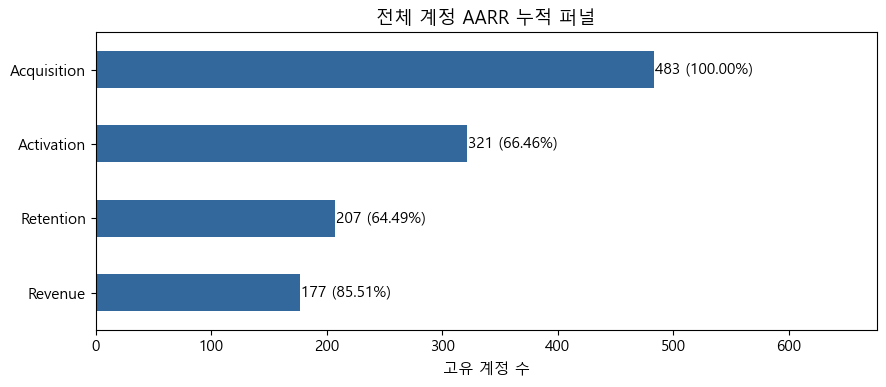

Activation → Retention 64.49%


In [3]:
def draw_account_funnel(f, title):
    ax=f['count'].plot.barh(color='#32689b',figsize=(9,4))
    for i,(_,r) in enumerate(f.iterrows()):
        label='—' if pd.isna(r.conversion_rate) else f'{r.conversion_rate:.2%}'
        ax.text(r['count']+1,i,f"{r['count']:.0f} ({label})",va='center')
    ax.invert_yaxis(); ax.set_xlim(0,max(f['count'].max()*1.4,1))
    ax.set(title=title,xlabel='고유 계정 수',ylabel=''); plt.tight_layout(); plt.show()
draw_account_funnel(funnel_summary,'전체 계정 AARR 누적 퍼널')
worst_stage = funnel_summary.conversion_rate.iloc[1:].idxmin()
worst_transition = stages[stages.index(worst_stage)-1]+' → '+worst_stage
print(worst_transition, f'{funnel_summary.loc[worst_stage,"conversion_rate"]:.2%}')

### 필수 2 답변
- **Q1.** Activation → Retention의 전환율이 64.49%로 가장 낮다.
- **Q2.** 원인은 확정되지 않는다. 가설 1은 초기 사용 오류가 반복 사용을 막는다는 것이다. 구독 시작 후 첫 30일의 오류·실패 기록과 이후 사용을 비교하고 오류 안내 개선을 실험한다. 가설 2는 반복 사용할 업무 사례를 이해하지 못한다는 것이다. 안내 노출·인터뷰를 수집하고 업무별 가이드 제공을 실험한다.
- **Q3.** 기능별 오류와 첫 성공 행동, 가이드 노출, 지원 문의 기록을 확인한다. 두 실험 모두 활성화 계정을 고정 배정하고 첫 구독 시작 후 30~60일 내 유효 사용 계정 비율을 동일하게 비교한다. 이 고정 창은 후속 실험용 정의이며 본 실습의 '30일 이후 한 번이라도 사용'과 구분한다.

---

## 과제 1. 평가 문항 기반 독립 과제

### 문제 3-1. 첫 구독 요금제별 퍼널 비교와 개선 가설 제안하기

#### 문제 설명

첫 구독의 plan_tier별로 Acquisition → Activation → Retention → Revenue 단계의 계정 수와 전환율을 비교하세요. 이탈이 집중된 구간을 찾고, 개선 가설과 검증 방법을 제안하세요.

> 필수 문제의 단계 정의와 집계·전환율 계산·시각화 절차를 그대로 활용합니다. Referral은 관련 행동 기록이 없어 분석에서 제외합니다.

#### 요구사항

1. 원시 계정·구독·기능 사용 데이터를 연결하여 funnel_base와 단계 도달 여부를 만드는 코드를 제출물에 포함하세요. 필수 문제에서 작성한 코드를 재사용해도 됩니다.
2. 첫 구독의 plan_tier별로 Acquisition, Activation, Retention, Revenue의 고유 계정 수를 집계하세요. 각 단계에는 이전 단계에 도달한 계정만 포함하세요.
3. 요금제별로 다음 값을 계산하여 plan_funnel을 만드세요.
- 구간 전환율 = 현재 단계 계정 수 ÷ 이전 단계 계정 수 × 100
- 구간 이탈률 = 100 − 구간 전환율
- 구간 이탈 계정 수 = 이전 단계 계정 수 − 현재 단계 계정 수
- 첫 단계는 비교할 이전 단계가 없으므로 구간 지표를 빈 값으로 두세요. 이전 단계 계정 수가 0이면 전환율·이탈률을 계산 불가로 표시하세요.
4. 요금제별로 단계별 고유 계정 수를 가로 막대그래프로 시각화하고, 각 단계의 구간 전환율을 함께 표시하세요.
5. 첫 단계를 제외하고 전환율이 가장 낮은 요금제·구간 조합을 찾으세요. 해당 구간의 전환율·이탈률·이탈 계정 수를 근거로 이탈 집중 구간을 설명하세요.
6. 요금제별 최종 Revenue 도달률을 계산하여 plan_summary로 출력하세요. 가장 높은 요금제와 낮은 요금제의 차이를 %p로 계산하세요.
- 최종 Revenue 도달률 = Revenue 계정 수 ÷ Acquisition 계정 수 × 100
7. 우선 점검할 구간에 대해 “어떤 원인 때문에 이탈하며, 어떤 변경을 하면 전환율이 개선될 것이다”라는 개선 가설을 한 가지 작성하세요.
8. 가설을 확인하기 위한 추가 데이터 2가지와 검증 방법을 설명하세요. 어떤 대상을 비교하고 어떤 지표로 개선 여부를 판단할지 포함하세요. 실제 실험이나 통계 검정은 수행하지 않아도 됩니다.

#### 해석 질문

Q1. 전환율이 가장 낮은 요금제와 구간은 무엇이며, 전환율·이탈률·이탈 계정 수는 얼마인가요?

Q2. 최종 Revenue 도달률이 가장 높은 요금제와 낮은 요금제는 무엇이며, 차이는 몇 %p인가요?

Q3. 우선 점검할 구간에 대한 개선 가설은 무엇이며, 어떤 데이터와 방법으로 검증할 수 있나요?

Q4. 요금제별 차이만으로 요금제가 이탈의 원인이라고 결론 내릴 수 있나요?

#### 제출 결과

- 원시 데이터 연결 및 단계 도달 여부 구성 코드
- plan_funnel: 단계별 계정 수·전환율·이탈률·이탈 계정 수
- 요금제별 퍼널 그래프
- 이탈 집중 구간과 수치 근거
- plan_summary: 최종 Revenue 도달률과 최고·최저 차이
- 개선 가설·추가 확인 데이터 2가지·검증 방법
- Q1~Q4 답변

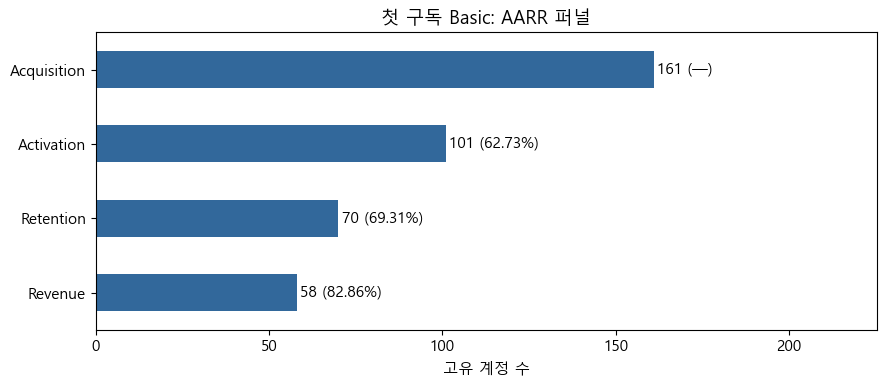

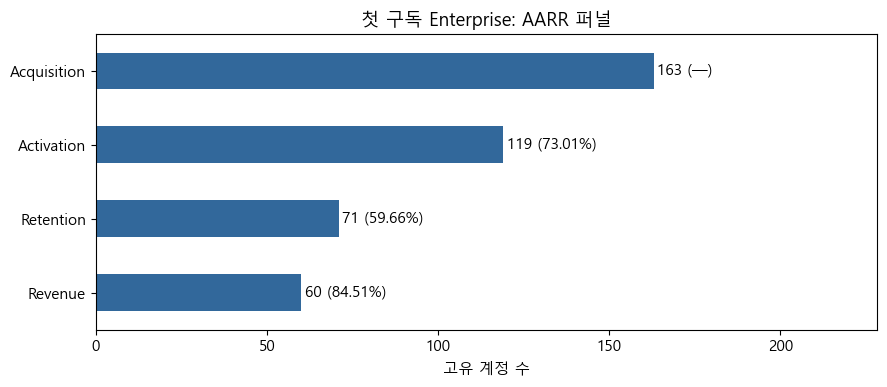

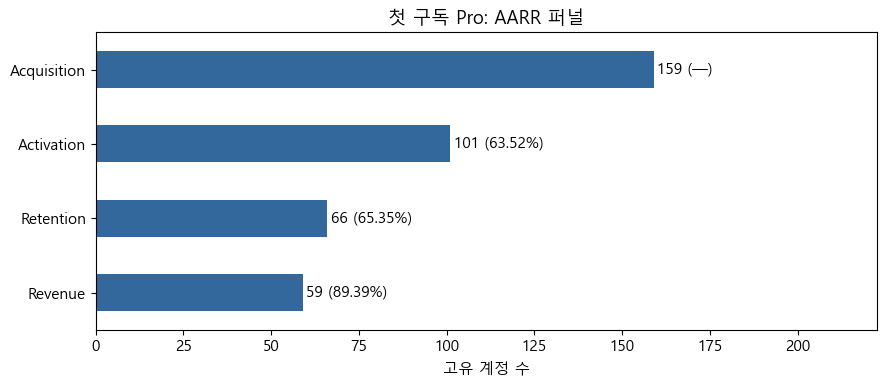

stage,Acquisition,Activation,Retention,Revenue,revenue_rate
plan_tier,,,,,
Basic,161,101,70,58,36.02%
Enterprise,163,119,71,60,36.81%
Pro,159,101,66,59,37.11%


최저 조합: ('Enterprise', 'Retention')


In [4]:
def build_funnel_base(accounts, subscriptions, feature_usage):
    first = subscriptions.sort_values(['start_date','subscription_id']).drop_duplicates('account_id')
    first_events = feature_usage.merge(first,on='subscription_id',validate='many_to_one')
    valid = first_events.loc[(first_events.usage_date >= first_events.start_date) & (first_events.end_date.isna() | (first_events.usage_date <= first_events.end_date))]
    retained_ids = set(valid.loc[valid.usage_date >= valid.start_date+pd.Timedelta(days=30),'account_id'])
    base = accounts.loc[accounts.signup_date <= observation_cutoff,['account_id','signup_date']].merge(first,on='account_id',how='left',validate='one_to_one')
    base['Acquisition'] = True
    base['Activation'] = (base.start_date >= base.signup_date) & (base.start_date <= base.signup_date+pd.Timedelta(days=30))
    base['Retention'] = base.Activation & base.account_id.isin(retained_ids)
    base['Revenue'] = base.Retention & base.is_trial.eq(False) & base.mrr_amount.gt(0)
    base['plan_tier'] = base.plan_tier.fillna('구독 없음')
    return base
funnel_base = build_funnel_base(accounts, subscriptions, feature_usage)
stages = ['Acquisition','Activation','Retention','Revenue']

plan_funnel = pd.concat({k:make_funnel([g.loc[g[s],'account_id'].nunique() for s in stages],stages) for k,g in funnel_base.groupby('plan_tier')},names=['plan_tier','stage'])
show_rates(plan_funnel)
for plan in plan_funnel.index.get_level_values(0).unique():
    draw_account_funnel(plan_funnel.loc[plan],f'첫 구독 {plan}: AARR 퍼널')
plan_summary = plan_funnel['count'].unstack()
plan_summary['revenue_rate'] = plan_summary.Revenue / plan_summary.Acquisition.replace(0,np.nan)
show_rates(plan_summary)
worst_plan = plan_funnel.conversion_rate.idxmin()
print('최저 조합:',worst_plan)

### 과제 1 답변
- **Q1.** ('Enterprise', 'Retention')의 바로 전 단계→해당 단계가 최저다. 전환율 59.66%, 이탈률 40.34%, 미도달 48개다.
- **Q2.** Revenue 도달률 최고 Pro (37.11%), 최저 Basic (36.02%), 차이는 1.08%p다.
- **Q3.** Enterprise의 초기 기능 오류와 활용법 이해 부족이 반복 사용을 막는다는 가설하에 오류 해결 안내와 업무별 가이드를 제공한다. 추가 데이터는 ① 첫 30일의 기능 오류·성공 행동 로그 ② 가이드 노출·지원 문의 기록이다. Enterprise의 Activation 계정을 기존/개선 안내에 고정 무작위 배정한다. 첫 구독 후 30~60일의 유효 사용 계정 수를 배정 계정 수로 나눈 비율로 비교하고 양군 모두 60일 관찰을 완료한다. 후속 실험의 고정 관찰 창은 본 실습의 30일 이후 사용 정의와 구분한다.
- **Q4.** 아니다. 첫 구독 요금제는 가입 이후 결정된 속성이며 고객 구성과 관찰 기간 차이가 있다. 요금제 자체의 인과 효과로 해석하지 않는다.

---

## 실습 마무리

1. 이번 분석에서는 각 AARR 단계를 어떤 조건으로 정의했나요?
2. 단계별 고유 계정 수는 어떤 코드로 집계했나요?
3. 전 단계 대비 전환율과 전체 대비 전환율은 각각 무엇을 보여주나요?
4. 어느 구간에서 이탈이 가장 집중되었나요?
5. 퍼널 수치와 이탈 원인을 왜 구분해야 하나요?
6. Referral 단계를 이번 분석에서 제외한 이유는 무엇인가요?

### 마무리 답변
1. 관찰 기회를 가진 가입→30일 이내 첫 구독→첫 구독 30일 이후 유효 사용→첫 구독 유료·양의 MRR로 정의했다.
2. groupby와 account_id.nunique를 사용했다.
3. 전 단계 대비는 구간 효율, 전체 대비는 최초 계정의 누적 도달을 보여준다.
4. 위 표의 최저 전환 구간을 우선 점검했다.
5. 미도달 수치는 원인을 알려주지 않으므로 추가 로그와 실험이 필요하다.
6. 추천 행동 이벤트가 없어 Referral은 제외했다.